# 15 · Capital allocation: where does the cash go?

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/valuein/valuein/blob/main/examples/notebooks/15_capital_allocation.ipynb)

**What you will learn**

- How to read a company's capital allocation from the cash-flow statement: reinvestment,
  acquisitions, buybacks, dividends, debt.
- How to compare several companies on the same basis over several years.
- Whether buybacks actually reduced the share count.

**Plan required:** none (free sample tier, last five fiscal years).

In [1]:
%pip install -q "valuein-sdk>=7.0.0" matplotlib

Note: you may need to restart the kernel to use updated packages.


## 1. The cash-flow uses

Operating cash flow (OCF) is what the business generates. Management then chooses how to use
it. The standardized concepts:

| Concept | Use of cash |
|---|---|
| `CAPEX` | reinvestment in property and equipment |
| `Acquisitions` | buying other businesses |
| `ShareBuyback` | repurchasing shares |
| `Dividends` | paying shareholders |
| `DebtRepayment` / `DebtIssuance` | paying down / raising debt |

Filers sign cash outflows differently, so take absolute values. All are annual values from
`fiscal_period = 'FY'` rows.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

from valuein_sdk import ValueinClient

client = ValueinClient()
TICKERS = ["AAPL", "MSFT", "GOOGL", "KO", "PG"]
CONCEPTS = ["OperatingCashFlow", "CAPEX", "Acquisitions", "ShareBuyback", "Dividends",
            "DebtRepayment", "DebtIssuance", "WeightedAvgSharesDiluted"]

ids = client.resolve(TICKERS)[["identifier", "cik"]]
cik_list = ", ".join(f"'{c}'" for c in ids["cik"])
concept_list = ", ".join(f"'{c}'" for c in CONCEPTS)
long = client.run_query(f"""
    SELECT entity_id AS cik, period_end, standard_concept, numeric_value
    FROM fact
    WHERE entity_id IN ({cik_list}) AND standard_concept IN ({concept_list})
      AND fiscal_period = 'FY' AND period_span_days BETWEEN 350 AND 380
    QUALIFY ROW_NUMBER() OVER (
        PARTITION BY entity_id, standard_concept, period_end ORDER BY accepted_at DESC, priority DESC) = 1
""")
data = (long.merge(ids, on="cik")
            .pivot_table(index=["identifier", "period_end"], columns="standard_concept",
                         values="numeric_value")
            .reindex(columns=CONCEPTS))
uses = ["CAPEX", "Acquisitions", "ShareBuyback", "Dividends"]
data[uses] = data[uses].abs()
data.loc["AAPL"].div(1e9).round(1)


Upgrade access:
  Register (free)  → Benchmark: full history for every S&P 500 constituent
  Add API token    → Full US equities universe + complete history

Get your token: https://valuein.biz
  client = ValueinClient()


standard_concept,OperatingCashFlow,CAPEX,Acquisitions,ShareBuyback,Dividends,DebtRepayment,DebtIssuance,WeightedAvgSharesDiluted
period_end,,,,,,,,
2021-09-25,104.0,11.1,0.0,86.0,14.5,8.8,20.4,16.9
2022-09-24,122.2,10.7,0.3,89.4,14.8,9.5,5.5,16.3
2023-09-30,110.5,11.0,NaN,77.6,15.0,11.2,5.2,15.8
2024-09-28,118.3,9.4,NaN,94.9,15.2,10.0,0.0,15.4
2025-09-27,111.5,12.7,NaN,90.7,15.4,10.9,4.5,15.0


Before comparing companies, check coverage: a missing value means the concept was not found in
that company's filing for that year (it may be reported under a line the standardization does
not map), not that the company spent nothing. Sums below skip missing years, so a gap understates
that use.

In [3]:
data[uses].notna().groupby(level="identifier").sum().rename(columns=lambda c: f"{c} years")

standard_concept,CAPEX years,Acquisitions years,ShareBuyback years,Dividends years
identifier,,,,
AAPL,5,2,5,5
GOOGL,5,0,5,4
KO,5,0,5,5
MSFT,6,0,6,6
PG,6,6,6,6


## 2. Five years of uses, as a share of operating cash flow

Summing over all fiscal years in the window smooths out one-off years (a large acquisition, a
special dividend). More than 100% means the company spent more than it generated, funded by
cash on hand or new debt.

In [4]:
totals = data.groupby(level="identifier")[["OperatingCashFlow", *uses]].sum()
share = totals[uses].div(totals["OperatingCashFlow"], axis=0) * 100
years = data.groupby(level="identifier").size().rename("fiscal_years")
share.join(years).round(1)

,CAPEX,Acquisitions,ShareBuyback,Dividends,fiscal_years
identifier,,,,,
AAPL,9.7,0.1,77.4,13.2,5
GOOGL,40.4,0.0,48.5,3.0,5
KO,18.0,0.0,12.9,80.8,5
MSFT,43.1,0.0,20.3,18.3,6
PG,18.8,2.1,41.1,50.8,6


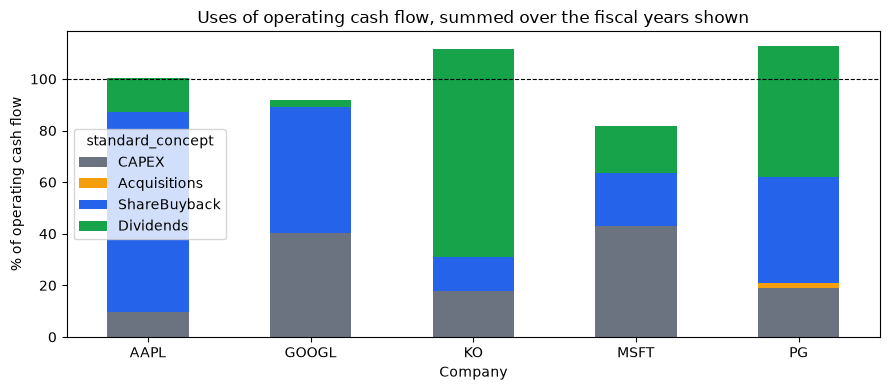

In [5]:
fig, ax = plt.subplots(figsize=(9, 4))
share.plot.bar(stacked=True, ax=ax, color=["#6b7280", "#f59e0b", "#2563eb", "#16a34a"])
ax.axhline(100, color="black", linewidth=0.8, linestyle="--")
ax.set_xlabel("Company")
ax.set_ylabel("% of operating cash flow")
ax.set_title("Uses of operating cash flow, summed over the fiscal years shown")
ax.set_xticklabels(share.index, rotation=0)
plt.tight_layout()
plt.show()

## 3. Did the buybacks shrink the share count?

Buybacks only return capital if they outpace the shares issued to employees. Compare the change
in diluted weighted shares from the first to the last fiscal year with the money spent.

In [6]:
shares = data["WeightedAvgSharesDiluted"].dropna().groupby(level="identifier")
result = pd.DataFrame({
    "first_year": shares.apply(lambda s: s.index[0][1].date()),
    "last_year": shares.apply(lambda s: s.index[-1][1].date()),
    "share_count_change": shares.last() / shares.first() - 1,
    "buybacks_bn": totals["ShareBuyback"] / 1e9,
})
result["share_count_change"] = result["share_count_change"].map("{:+.1%}".format)
result.round(1)

,first_year,last_year,share_count_change,buybacks_bn
identifier,,,,
AAPL,2021-09-25,2025-09-27,-11.0%,438.6
GOOGL,2022-12-31,2025-12-31,-7.1%,279.0
KO,2021-12-31,2025-12-31,-0.6%,6.4
MSFT,2021-06-30,2026-06-30,-2.0%,140.3
PG,2021-06-30,2026-06-30,-6.9%,44.9


In [7]:
client.close()

## Next steps

- **[16 · Filing delay](16_filing_delay.ipynb)**.
- Turn this into a cross-sectional signal (for example shareholder yield = buybacks plus
  dividends over market value) and test it with the backtest in notebook 04.